In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [40]:
t_array = np.linspace(0.0001,12,int(1e3))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_const = np.ones(len(t_array))

# 1) $\alpha_{cc}$

## 1.1) Constant SFR

In [41]:
gals_c = []
alpha_ccs = [-0.1, 0.2, 0.4]

#gals_c are for constant SFR
for alpha_cc in alpha_ccs:
    gals_c.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, alpha_cc_Mn=alpha_cc))

#gals_e are for exponential SFR
gals_e = []

for alpha_cc in alpha_ccs:
    gals_e.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, alpha_cc_Mn=alpha_cc))

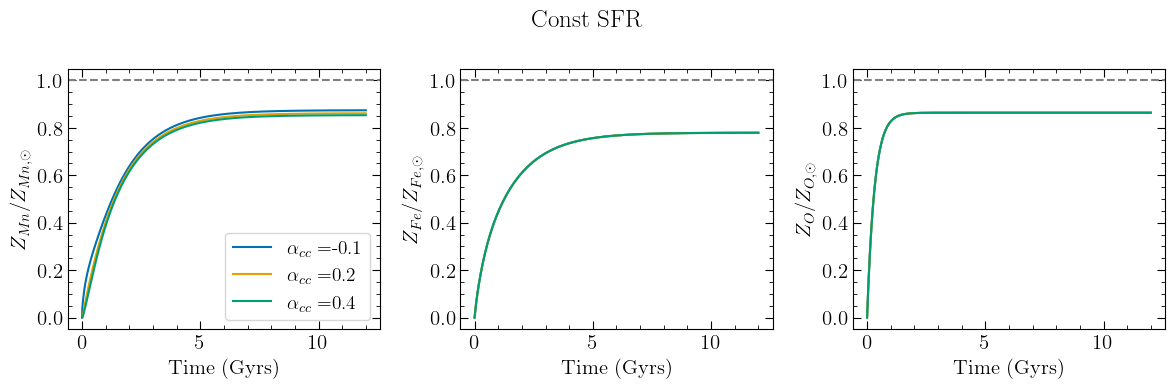

In [42]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
for i in range(len(alpha_ccs)):
    plt.plot(t_array, gals_c[i].compute_z_Mn()/gals_c[i].SolarMn, label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i])
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn, \odot}$')
plt.axhline(1, color = 'gray', linestyle='--')
plt.legend()

plt.subplot(1,3,2)
for i in range(len(alpha_ccs)):
    plt.plot(t_array, gals_c[i].compute_z_Fe()/gals_c[i].SolarFe, label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i])
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Fe}/Z_{Fe, \odot}$')

plt.subplot(1,3,3)
for i in range(len(alpha_ccs)):
    plt.plot(t_array, gals_c[i].compute_z_O()/gals_c[i].SolarO, label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i])
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{O}/Z_{O, \odot}$')

plt.suptitle('Const SFR')
plt.tight_layout()

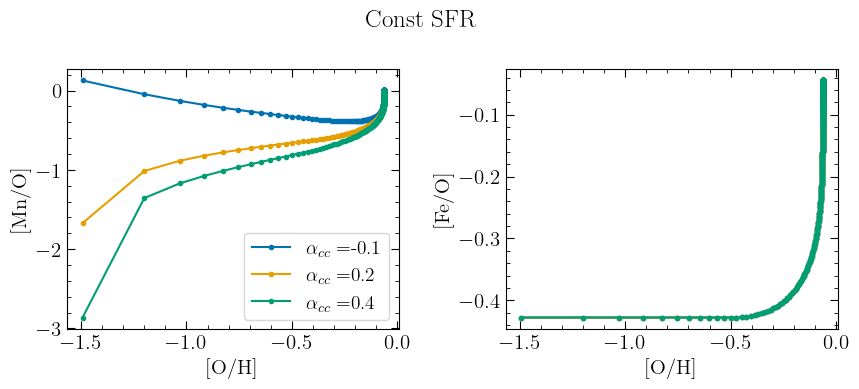

In [43]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
for i in range(len(alpha_ccs)):
    plt.plot(gals_c[i].O_H[1:], gals_c[i].Mn_O[1:], label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i],
             marker='o', markersize = 3)
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()

plt.subplot(1,2,2)
for i in range(len(alpha_ccs)):
    plt.plot(gals_c[i].O_H[1:], gals_c[i].Fe_O[1:], label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i],
             marker='o', markersize = 3)
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.suptitle('Const SFR')
plt.tight_layout()

## 1.2) Exp SFR

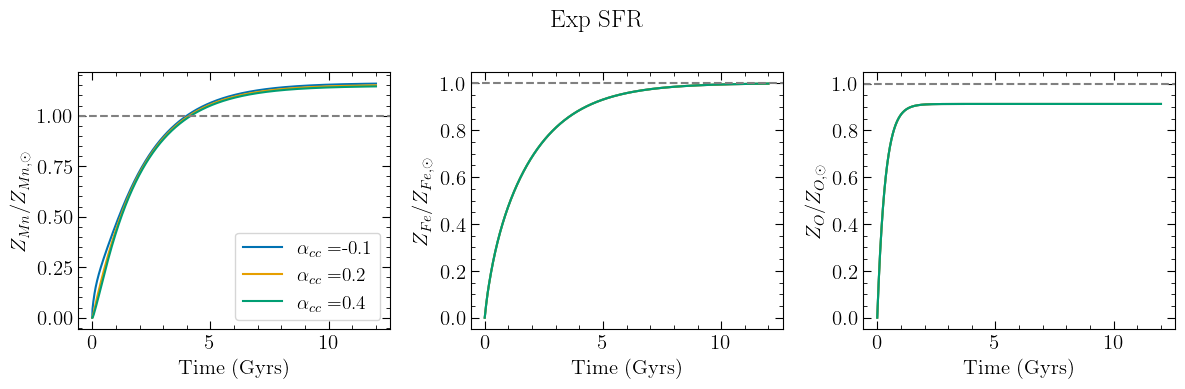

In [44]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
for i in range(len(alpha_ccs)):
    plt.plot(t_array, gals_e[i].compute_z_Mn()/gals_e[i].SolarMn, label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i])
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Mn}/Z_{Mn, \odot}$')
plt.axhline(1, color = 'gray', linestyle='--')
plt.legend()

plt.subplot(1,3,2)
for i in range(len(alpha_ccs)):
    plt.plot(t_array, gals_e[i].compute_z_Fe()/gals_e[i].SolarFe, label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i])
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{Fe}/Z_{Fe, \odot}$')

plt.subplot(1,3,3)
for i in range(len(alpha_ccs)):
    plt.plot(t_array, gals_e[i].compute_z_O()/gals_e[i].SolarO, label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i])
plt.axhline(1, color = 'gray', linestyle='--')
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$Z_{O}/Z_{O, \odot}$')

plt.suptitle('Exp SFR')
plt.tight_layout()

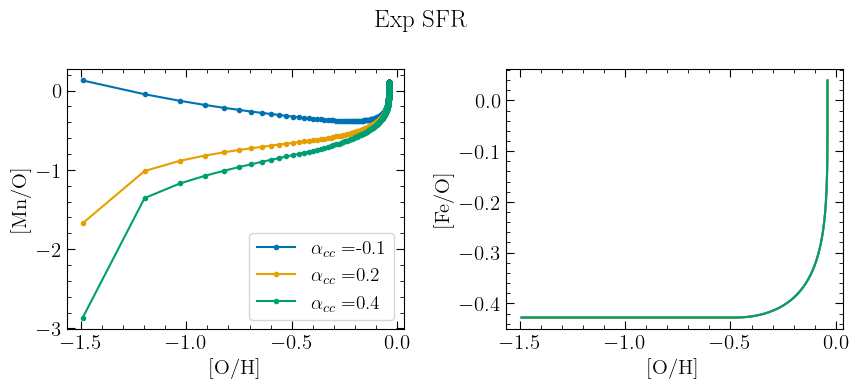

In [45]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
for i in range(len(alpha_ccs)):
    plt.plot(gals_e[i].O_H[1:], gals_e[i].Mn_O[1:], label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i],
             marker='o', markersize = 3)
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()

plt.subplot(1,2,2)
for i in range(len(alpha_ccs)):
    plt.plot(gals_e[i].O_H[1:], gals_e[i].Fe_O[1:], label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i])
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

plt.suptitle('Exp SFR')
plt.tight_layout()

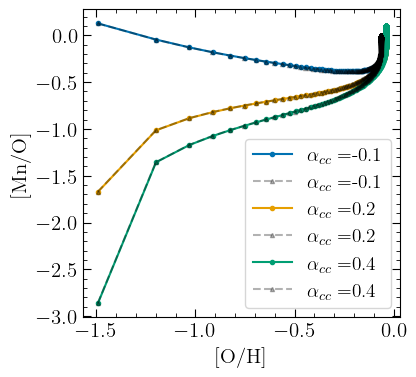

In [50]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
for i in range(len(alpha_ccs)):
    plt.plot(gals_e[i].O_H[1:], gals_e[i].Mn_O[1:], label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = colors[i],
             marker='o', markersize = 3)
    plt.plot(gals_c[i].O_H[1:], gals_c[i].Mn_O[1:], label = r"$\alpha_{cc} = $" + f"{alpha_ccs[i]}", color = 'black', linestyle = '--', alpha = 0.3,
             marker='^', markersize = 3)
    
plt.xlabel('[O/H]')
plt.ylabel('[Mn/O]')
plt.legend()